# Bloque I — Análisis Descriptivo del Dataset Iris

**Duración estimada:** 3 horas  
**Modalidad:** explicación + demostración guiada + práctica individual  
**Dataset:** `Iris.csv`

## Objetivo de aprendizaje

Al finalizar la sesión, el alumnado será capaz de cargar, inspeccionar, limpiar, transformar, describir y visualizar el famoso dataset Iris con Python y `pandas`, generando conclusiones iniciales útiles para un proyecto de análisis de datos.

## El Dataset Iris

El dataset Iris es uno de los datasets más famosos en el mundo del aprendizaje automático y la estadística. Fue introducido por el estadístico Ronald Fisher en 1936.

**Características del dataset:**
- **150 muestras** (50 por especie)
- **3 especies** de iris: *Iris-setosa*, *Iris-versicolor*, e *Iris-virginica*
- **4 características (features)**:
  - Longitud del sépalo (SepalLengthCm)
  - Ancho del sépalo (SepalWidthCm)
  - Longitud del pétalo (PetalLengthCm)
  - Ancho del pétalo (PetalWidthCm)

## Agenda de 3 horas

| Tiempo | Actividad |
|---:|---|
| 0:00–0:20 | Ecosistema Python para análisis de datos |
| 0:20–0:50 | Repaso de estructuras básicas de Python |
| 0:50–1:25 | Introducción práctica a `numpy` y `pandas` |
| 1:25–1:35 | Pausa |
| 1:35–2:15 | Carga, exploración y limpieza de datos |
| 2:15–2:45 | Análisis descriptivo y visualización |
| 2:45–3:00 | Ejercicio integrador y conclusiones |

In [1]:
# Configuración común
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de pandas para mejor visualización
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Configuración de seaborn para gráficos más atractivos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

print("Librerías cargadas correctamente.")
print(f"NumPy versión: {np.__version__}")
print(f"Pandas versión: {pd.__version__}")
print(f"Seaborn versión: {sns.__version__}")

Librerías cargadas correctamente.
NumPy versión: 2.4.4
Pandas versión: 3.0.2
Seaborn versión: 0.13.2


## 1. Repaso aplicado de Python

En análisis de datos no se necesita dominar todo Python desde el primer día, pero sí comprender las estructuras que se usarán de forma continua:

- variables,
- listas,
- diccionarios,
- condicionales,
- bucles,
- funciones.

La idea importante es que Python permite expresar reglas de negocio y transformaciones de datos de forma clara.

In [2]:
# Ejemplo aplicado al dataset Iris

# Variables básicas
species_count = 3
feature_count = 4
dataset_name = "Iris"

# Lista con las especies de iris
species_list = ["Iris-setosa", "Iris-versicolor", "Iris-virginica"]

# Diccionario con información del dataset
iris_info = {
    "nombre": "Iris",
    "muestras": 150,
    "especies": 3,
    "caracteristicas": 4,
    "año_origen": 1936
}

# Función para clasificar una muestra según el ancho del pétalo
def clasificar_petalo(ancho_petalo):
    """Clasifica una flor según el ancho de su pétalo."""
    if ancho_petalo < 0.5:
        return "Pétalo estrecho (probablemente Setosa)"
    elif ancho_petalo < 1.5:
        return "Pétalo medio (probablemente Versicolor)"
    else:
        return "Pétalo ancho (probablemente Virginica)"

# Ejemplo de uso
for ancho in [0.2, 0.8, 1.2, 1.8, 2.3]:
    print(f"Ancho {ancho}cm -> {clasificar_petalo(ancho)}")

Ancho 0.2cm -> Pétalo estrecho (probablemente Setosa)
Ancho 0.8cm -> Pétalo medio (probablemente Versicolor)
Ancho 1.2cm -> Pétalo medio (probablemente Versicolor)
Ancho 1.8cm -> Pétalo ancho (probablemente Virginica)
Ancho 2.3cm -> Pétalo ancho (probablemente Virginica)


## 2. Introducción a NumPy

`numpy` permite trabajar con arrays y operaciones vectorizadas. Esto es clave porque en análisis de datos se procesan columnas completas, no elemento a elemento.

In [3]:
# Crear arrays de ejemplo con medidas de sépalos
sepal_lengths = np.array([5.1, 4.9, 4.7, 4.6, 5.0, 5.4, 4.6, 5.0, 4.4, 4.9])
sepal_widths = np.array([3.5, 3.0, 3.2, 3.1, 3.6, 3.9, 3.4, 3.4, 2.9, 3.1])

print("=== Medidas de Sépalos (primeras 10 muestras) ===")
print("Longitud del sépalo:", sepal_lengths)
print("Ancho del sépalo:", sepal_widths)
print("\n=== Estadísticas con NumPy ===")
print("Media longitud sépalo:", np.mean(sepal_lengths))
print("Mediana longitud sépalo:", np.median(sepal_lengths))
print("Desviación típica longitud sépalo:", np.std(sepal_lengths))
print("\nÁrea aproximada del sépalo (longitud * ancho):", sepal_lengths * sepal_widths)
print("\nSuma total de longitudes:", np.sum(sepal_lengths))
print("Valor máximo:", np.max(sepal_lengths))
print("Valor mínimo:", np.min(sepal_lengths))

=== Medidas de Sépalos (primeras 10 muestras) ===
Longitud del sépalo: [5.1 4.9 4.7 4.6 5.  5.4 4.6 5.  4.4 4.9]
Ancho del sépalo: [3.5 3.  3.2 3.1 3.6 3.9 3.4 3.4 2.9 3.1]

=== Estadísticas con NumPy ===
Media longitud sépalo: 4.859999999999999
Mediana longitud sépalo: 4.9
Desviación típica longitud sépalo: 0.2764054992217051

Área aproximada del sépalo (longitud * ancho): [17.85 14.7  15.04 14.26 18.   21.06 15.64 17.   12.76 15.19]

Suma total de longitudes: 48.599999999999994
Valor máximo: 5.4
Valor mínimo: 4.4


## 3. Carga de datos con pandas

`pandas` es la librería principal para trabajar con datos tabulares. Su estructura central es el `DataFrame`, equivalente a una tabla con filas y columnas.

El dataset Iris contiene 150 muestras con 4 características y una columna de especie.

In [4]:
# Cargar el dataset Iris
df = pd.read_csv("Iris.csv")

# Mostrar las primeras filas
print("Primeras 10 filas del dataset:")
df.head(10)

Primeras 10 filas del dataset:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.100,3.500,1.400,0.200,Iris-setosa
1,2,4.900,3.000,1.400,0.200,Iris-setosa
2,3,4.700,3.200,1.300,0.200,Iris-setosa
3,4,4.600,3.100,1.500,0.200,Iris-setosa
4,5,5.000,3.600,1.400,0.200,Iris-setosa
5,6,5.400,3.900,1.700,0.400,Iris-setosa
6,7,4.600,3.400,1.400,0.300,Iris-setosa
7,8,5.000,3.400,1.500,0.200,Iris-setosa
8,9,4.400,2.900,1.400,0.200,Iris-setosa
9,10,4.900,3.100,1.500,0.100,Iris-setosa


In [5]:
# Información básica del dataset
print("="*50)
print("INFORMACIÓN DEL DATASET IRIS")
print("="*50)
print(f"\nForma del dataset (filas, columnas): {df.shape}")
print(f"\nColumnas del dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

# Usar df.info() para información detallada
print("\n" + "="*50)
print("INFORMACIÓN DETALLADA (df.info())")
print("="*50)
df.info()

INFORMACIÓN DEL DATASET IRIS

Forma del dataset (filas, columnas): (150, 6)

Columnas del dataset:
  1. Id
  2. SepalLengthCm
  3. SepalWidthCm
  4. PetalLengthCm
  5. PetalWidthCm
  6. Species

INFORMACIÓN DETALLADA (df.info())
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


## 4. Exploración inicial

Antes de limpiar o modelizar, debemos entender el dataset:

- qué columnas tiene,
- qué tipo de datos contiene,
- cuántos registros hay,
- si hay valores nulos,
- si existen duplicados,
- qué rango tienen las variables numéricas.

In [6]:
# Estadísticas descriptivas
print("="*50)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("="*50)
display(df.describe())

# Verificar valores nulos
print("\n" + "="*50)
print("VALORES NULOS POR COLUMNA")
print("="*50)
nulos = df.isnull().sum()
print(nulos)
print(f"\n¿Hay algún valor nulo? {nulos.any()}")

# Verificar duplicados
print("\n" + "="*50)
print("DUPLICADOS")
print("="*50)
duplicados = df.duplicated().sum()
print(f"Número de filas duplicadas: {duplicados}")

# Contar especies únicas
print("\n" + "="*50)
print("ESPECIES ÚNICAS")
print("="*50)
species_counts = df['Species'].value_counts()
print(species_counts)
print(f"\nNúmero de especies únicas: {df['Species'].nunique()}")
print(f"Especies: {df['Species'].unique().tolist()}")

ESTADÍSTICAS DESCRIPTIVAS


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000,150.000,150.000,150.000,150.000
mean,75.500,5.843,3.054,3.759,1.199
std,43.445,0.828,0.434,1.764,0.763
min,1.000,4.300,2.000,1.000,0.100
25%,38.250,5.100,2.800,1.600,0.300
50%,75.500,5.800,3.000,4.350,1.300
75%,112.750,6.400,3.300,5.100,1.800
max,150.000,7.900,4.400,6.900,2.500



VALORES NULOS POR COLUMNA
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

¿Hay algún valor nulo? False

DUPLICADOS
Número de filas duplicadas: 0

ESPECIES ÚNICAS
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Número de especies únicas: 3
Especies: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


## 5. Limpieza básica

En un proyecto real, la limpieza debe documentarse. No basta con modificar los datos: hay que explicar qué se ha hecho y por qué.

Para el dataset Iris:

- La columna `Id` es un identificador que no aporta información para el análisis, podemos decidir si mantenerla o no.
- Verificamos si hay valores faltantes (ya vimos que no los hay).
- Verificamos duplicados (ya vimos que no los hay).
- Podemos crear características derivadas si es útil.

In [7]:
# Crear una copia para trabajar
df_clean = df.copy()

# Opcionalmente, podemos eliminar la columna Id si no la necesitamos
# En este caso, la mantendremos pero sepamos que está ahí
print("Columnas antes de limpieza:", df_clean.columns.tolist())

# Verificar si la columna Id es realmente única
print(f"\nValores únicos en Id: {df_clean['Id'].nunique()}")
print(f"Total de filas: {len(df_clean)}")

# Crear variables derivadas: relación entre longitud y ancho
df_clean['SepalRatio'] = df_clean['SepalLengthCm'] / df_clean['SepalWidthCm']
df_clean['PetalRatio'] = df_clean['PetalLengthCm'] / df_clean['PetalWidthCm']

print("\nNuevas columnas creadas: SepalRatio, PetalRatio")
print("\nPrimeras 5 filas con nuevas columnas:")
df_clean[['Id', 'SepalLengthCm', 'SepalWidthCm', 'SepalRatio', 'PetalLengthCm', 'PetalWidthCm', 'PetalRatio', 'Species']].head()

Columnas antes de limpieza: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Valores únicos en Id: 150
Total de filas: 150

Nuevas columnas creadas: SepalRatio, PetalRatio

Primeras 5 filas con nuevas columnas:


,Id,SepalLengthCm,SepalWidthCm,SepalRatio,PetalLengthCm,PetalWidthCm,PetalRatio,Species
0,1,5.100,3.500,1.457,1.400,0.200,7.000,Iris-setosa
1,2,4.900,3.000,1.633,1.400,0.200,7.000,Iris-setosa
2,3,4.700,3.200,1.469,1.300,0.200,6.500,Iris-setosa
3,4,4.600,3.100,1.484,1.500,0.200,7.500,Iris-setosa
4,5,5.000,3.600,1.389,1.400,0.200,7.000,Iris-setosa


## 6. Análisis descriptivo por especie

El análisis descriptivo resume el comportamiento de los datos. Responde preguntas como:

- ¿cuál es la media de cada característica?
- ¿qué especie tiene sépalos más largos?
- ¿cómo se distribuyen las características?
- ¿existen diferencias claras entre especies?

In [8]:
# Análisis descriptivo por especie
print("="*50)
print("ESTADÍSTICAS POR ESPECIE")
print("="*50)

# Agrupar por especie y calcular estadísticas
for species in df_clean['Species'].unique():
    print(f"\n>>> {species.upper()} <<<")
    subset = df_clean[df_clean['Species'] == species]
    print(f"  Muestras: {len(subset)}")
    print(f"  Longitud sépalo - Media: {subset['SepalLengthCm'].mean():.2f}cm, Mediana: {subset['SepalLengthCm'].median():.2f}cm")
    print(f"  Ancho sépalo - Media: {subset['SepalWidthCm'].mean():.2f}cm, Mediana: {subset['SepalWidthCm'].median():.2f}cm")
    print(f"  Longitud pétalo - Media: {subset['PetalLengthCm'].mean():.2f}cm, Mediana: {subset['PetalLengthCm'].median():.2f}cm")
    print(f"  Ancho pétalo - Media: {subset['PetalWidthCm'].mean():.2f}cm, Mediana: {subset['PetalWidthCm'].median():.2f}cm")

ESTADÍSTICAS POR ESPECIE

>>> IRIS-SETOSA <<<
  Muestras: 50
  Longitud sépalo - Media: 5.01cm, Mediana: 5.00cm
  Ancho sépalo - Media: 3.42cm, Mediana: 3.40cm
  Longitud pétalo - Media: 1.46cm, Mediana: 1.50cm
  Ancho pétalo - Media: 0.24cm, Mediana: 0.20cm

>>> IRIS-VERSICOLOR <<<
  Muestras: 50
  Longitud sépalo - Media: 5.94cm, Mediana: 5.90cm
  Ancho sépalo - Media: 2.77cm, Mediana: 2.80cm
  Longitud pétalo - Media: 4.26cm, Mediana: 4.35cm
  Ancho pétalo - Media: 1.33cm, Mediana: 1.30cm

>>> IRIS-VIRGINICA <<<
  Muestras: 50
  Longitud sépalo - Media: 6.59cm, Mediana: 6.50cm
  Ancho sépalo - Media: 2.97cm, Mediana: 3.00cm
  Longitud pétalo - Media: 5.55cm, Mediana: 5.55cm
  Ancho pétalo - Media: 2.03cm, Mediana: 2.00cm


In [9]:
# Estadísticas agrupadas con pandas
stats_by_species = df_clean.groupby('Species').agg({
    'SepalLengthCm': ['mean', 'median', 'std', 'min', 'max'],
    'SepalWidthCm': ['mean', 'median', 'std', 'min', 'max'],
    'PetalLengthCm': ['mean', 'median', 'std', 'min', 'max'],
    'PetalWidthCm': ['mean', 'median', 'std', 'min', 'max']
})

print("Resumen estadístico por especie:")
stats_by_species

Resumen estadístico por especie:

SepalLengthCm                          SepalWidthCm         \
                         mean median   std   min   max         mean median   
Species                                                                      
Iris-setosa             5.006  5.000 0.352 4.300 5.800        3.418  3.400   
Iris-versicolor         5.936  5.900 0.516 4.900 7.000        2.770  2.800   
Iris-virginica          6.588  6.500 0.636 4.900 7.900        2.974  3.000   

                                  PetalLengthCm                           \
                  std   min   max          mean median   std   min   max   
Species                                                                    
Iris-setosa     0.381 2.300 4.400         1.464  1.500 0.174 1.000 1.900   
Iris-versicolor 0.314 2.000 3.400         4.260  4.350 0.470 3.000 5.100   
Iris-virginica  0.322 2.200 3.800         5.552  5.550 0.552 4.500 6.900   

                PetalWidthCm                           
                        mean median   std   min   max  
Species                                                
Iris-setosa            0.244  0.200 0.107 0.100 0.600  
Iris-versicolor        1.326  1.300 0.198 1.000 1.800  
Iris-virginica         2.026  2.000 0.275 1.400 2.500

## 7. Visualización de datos

La visualización permite detectar patrones rápidamente. En esta sesión trabajamos con:

- histogramas (distribución de datos),
- boxplots (comparación entre grupos),
- scatter plots (relaciones entre variables),
- pairplot (vista general de todas las relaciones).

HISTOGRAMAS - DISTRIBUCIÓN DE CARACTERÍSTICAS


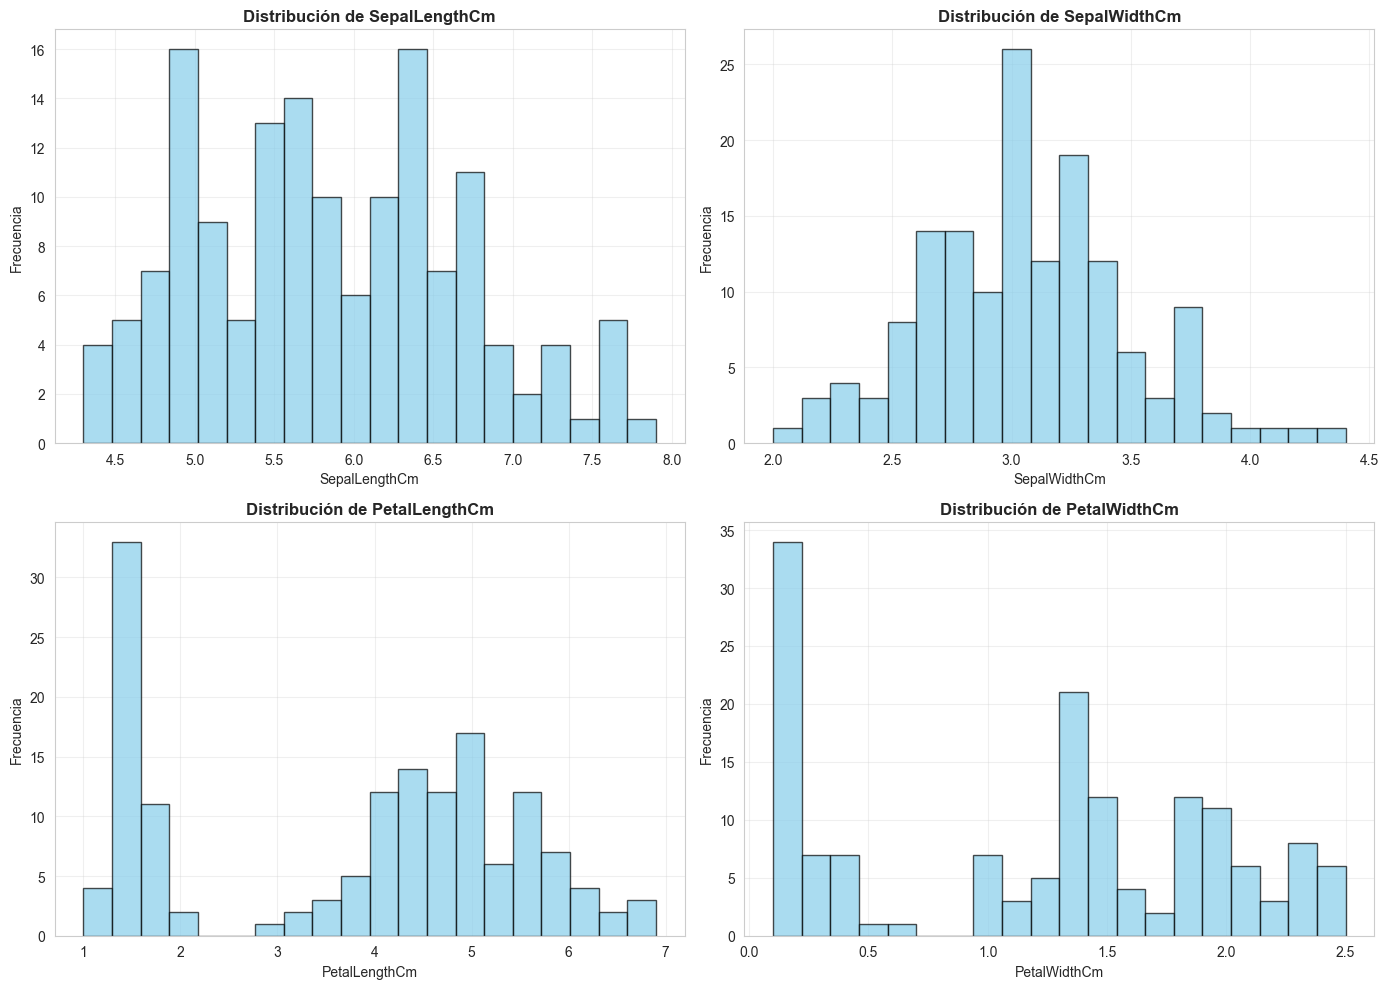

In [10]:
# Configuración de colores por especie
colors = {'Iris-setosa': 'blue', 'Iris-versicolor': 'orange', 'Iris-virginica': 'green'}

# 1. HISTOGRAMAS - Distribución de cada característica
print("="*50)
print("HISTOGRAMAS - DISTRIBUCIÓN DE CARACTERÍSTICAS")
print("="*50)

features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, feature in enumerate(features):
    axes[i].hist(df_clean[feature], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribución de {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

BOXPLOTS - COMPARACIÓN ENTRE ESPECIES


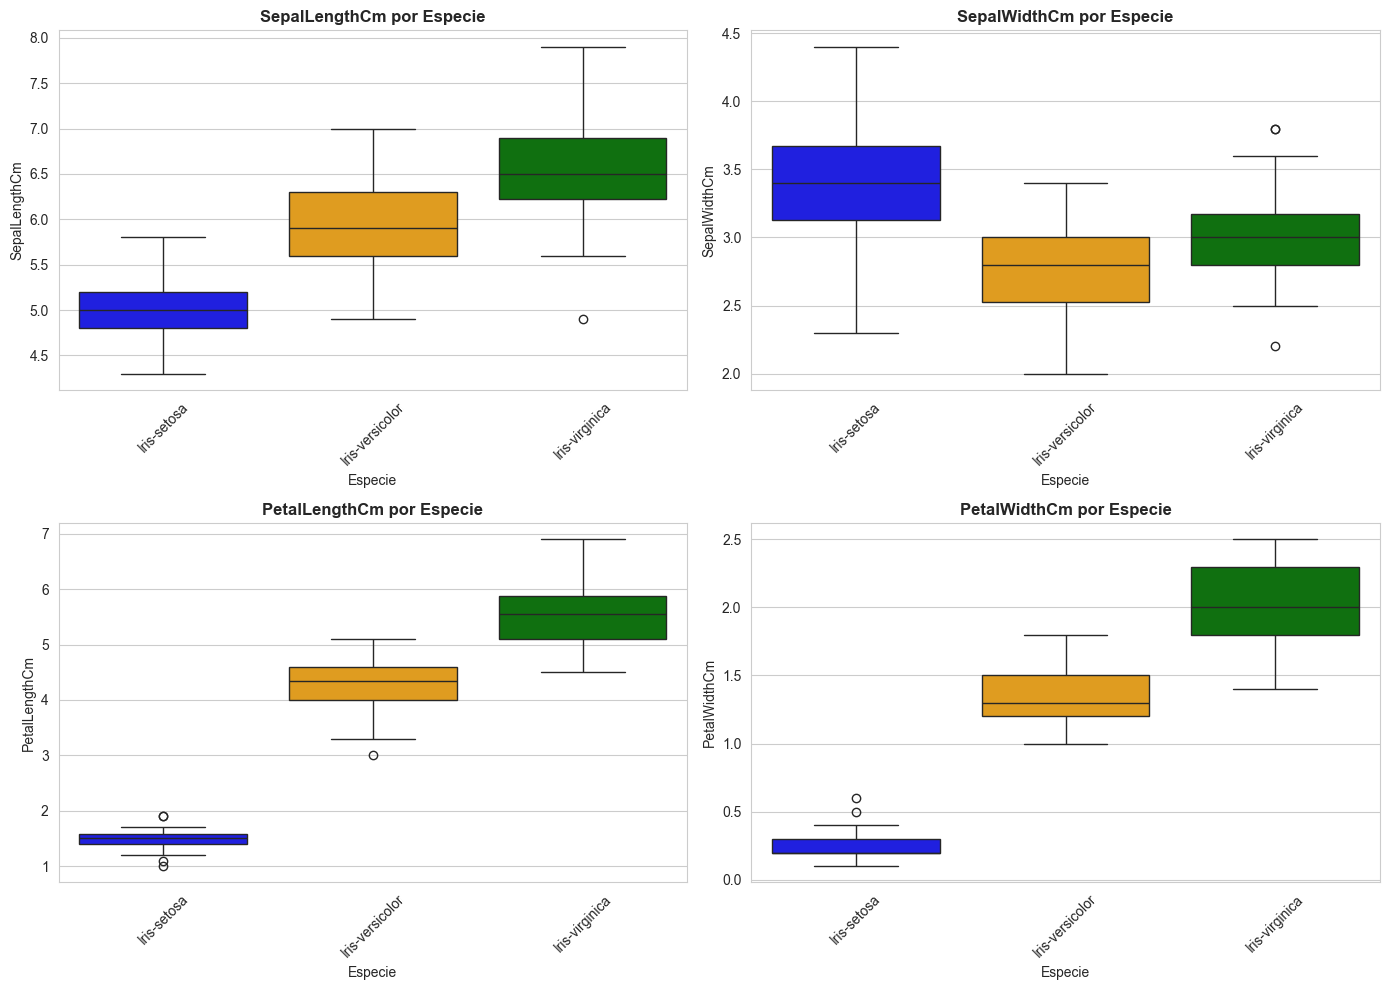

In [11]:
# 2. BOXPLOTS - Comparación entre especies
print("="*50)
print("BOXPLOTS - COMPARACIÓN ENTRE ESPECIES")
print("="*50)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, feature in enumerate(features):
    sns.boxplot(data=df_clean, x='Species', y=feature, ax=axes[i], palette=colors)
    axes[i].set_title(f'{feature} por Especie', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Especie')
    axes[i].set_ylabel(feature)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

SCATTER PLOTS - RELACIONES ENTRE VARIABLES


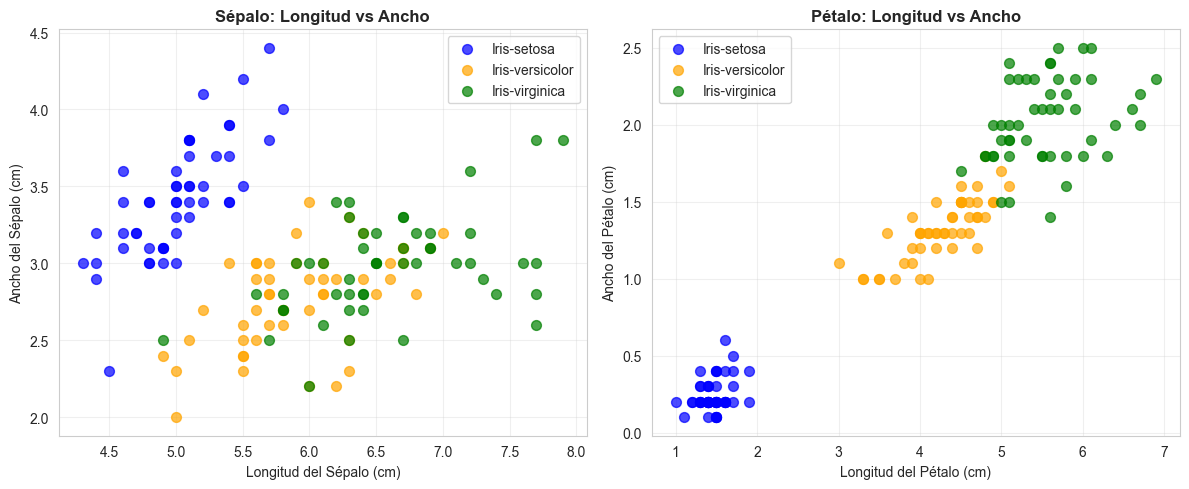

In [12]:
# 3. SCATTER PLOTS - Relaciones entre variables
print("="*50)
print("SCATTER PLOTS - RELACIONES ENTRE VARIABLES")
print("="*50)

# Scatter plot: Sepal Length vs Sepal Width
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for species in df_clean['Species'].unique():
    subset = df_clean[df_clean['Species'] == species]
    plt.scatter(subset['SepalLengthCm'], subset['SepalWidthCm'], 
                label=species, color=colors[species], alpha=0.7, s=50)
plt.xlabel('Longitud del Sépalo (cm)')
plt.ylabel('Ancho del Sépalo (cm)')
plt.title('Sépalo: Longitud vs Ancho', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Scatter plot: Petal Length vs Petal Width
plt.subplot(1, 2, 2)
for species in df_clean['Species'].unique():
    subset = df_clean[df_clean['Species'] == species]
    plt.scatter(subset['PetalLengthCm'], subset['PetalWidthCm'], 
                label=species, color=colors[species], alpha=0.7, s=50)
plt.xlabel('Longitud del Pétalo (cm)')
plt.ylabel('Ancho del Pétalo (cm)')
plt.title('Pétalo: Longitud vs Ancho', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

PAIRPLOT - VISTA GENERAL DE TODAS LAS RELACIONES


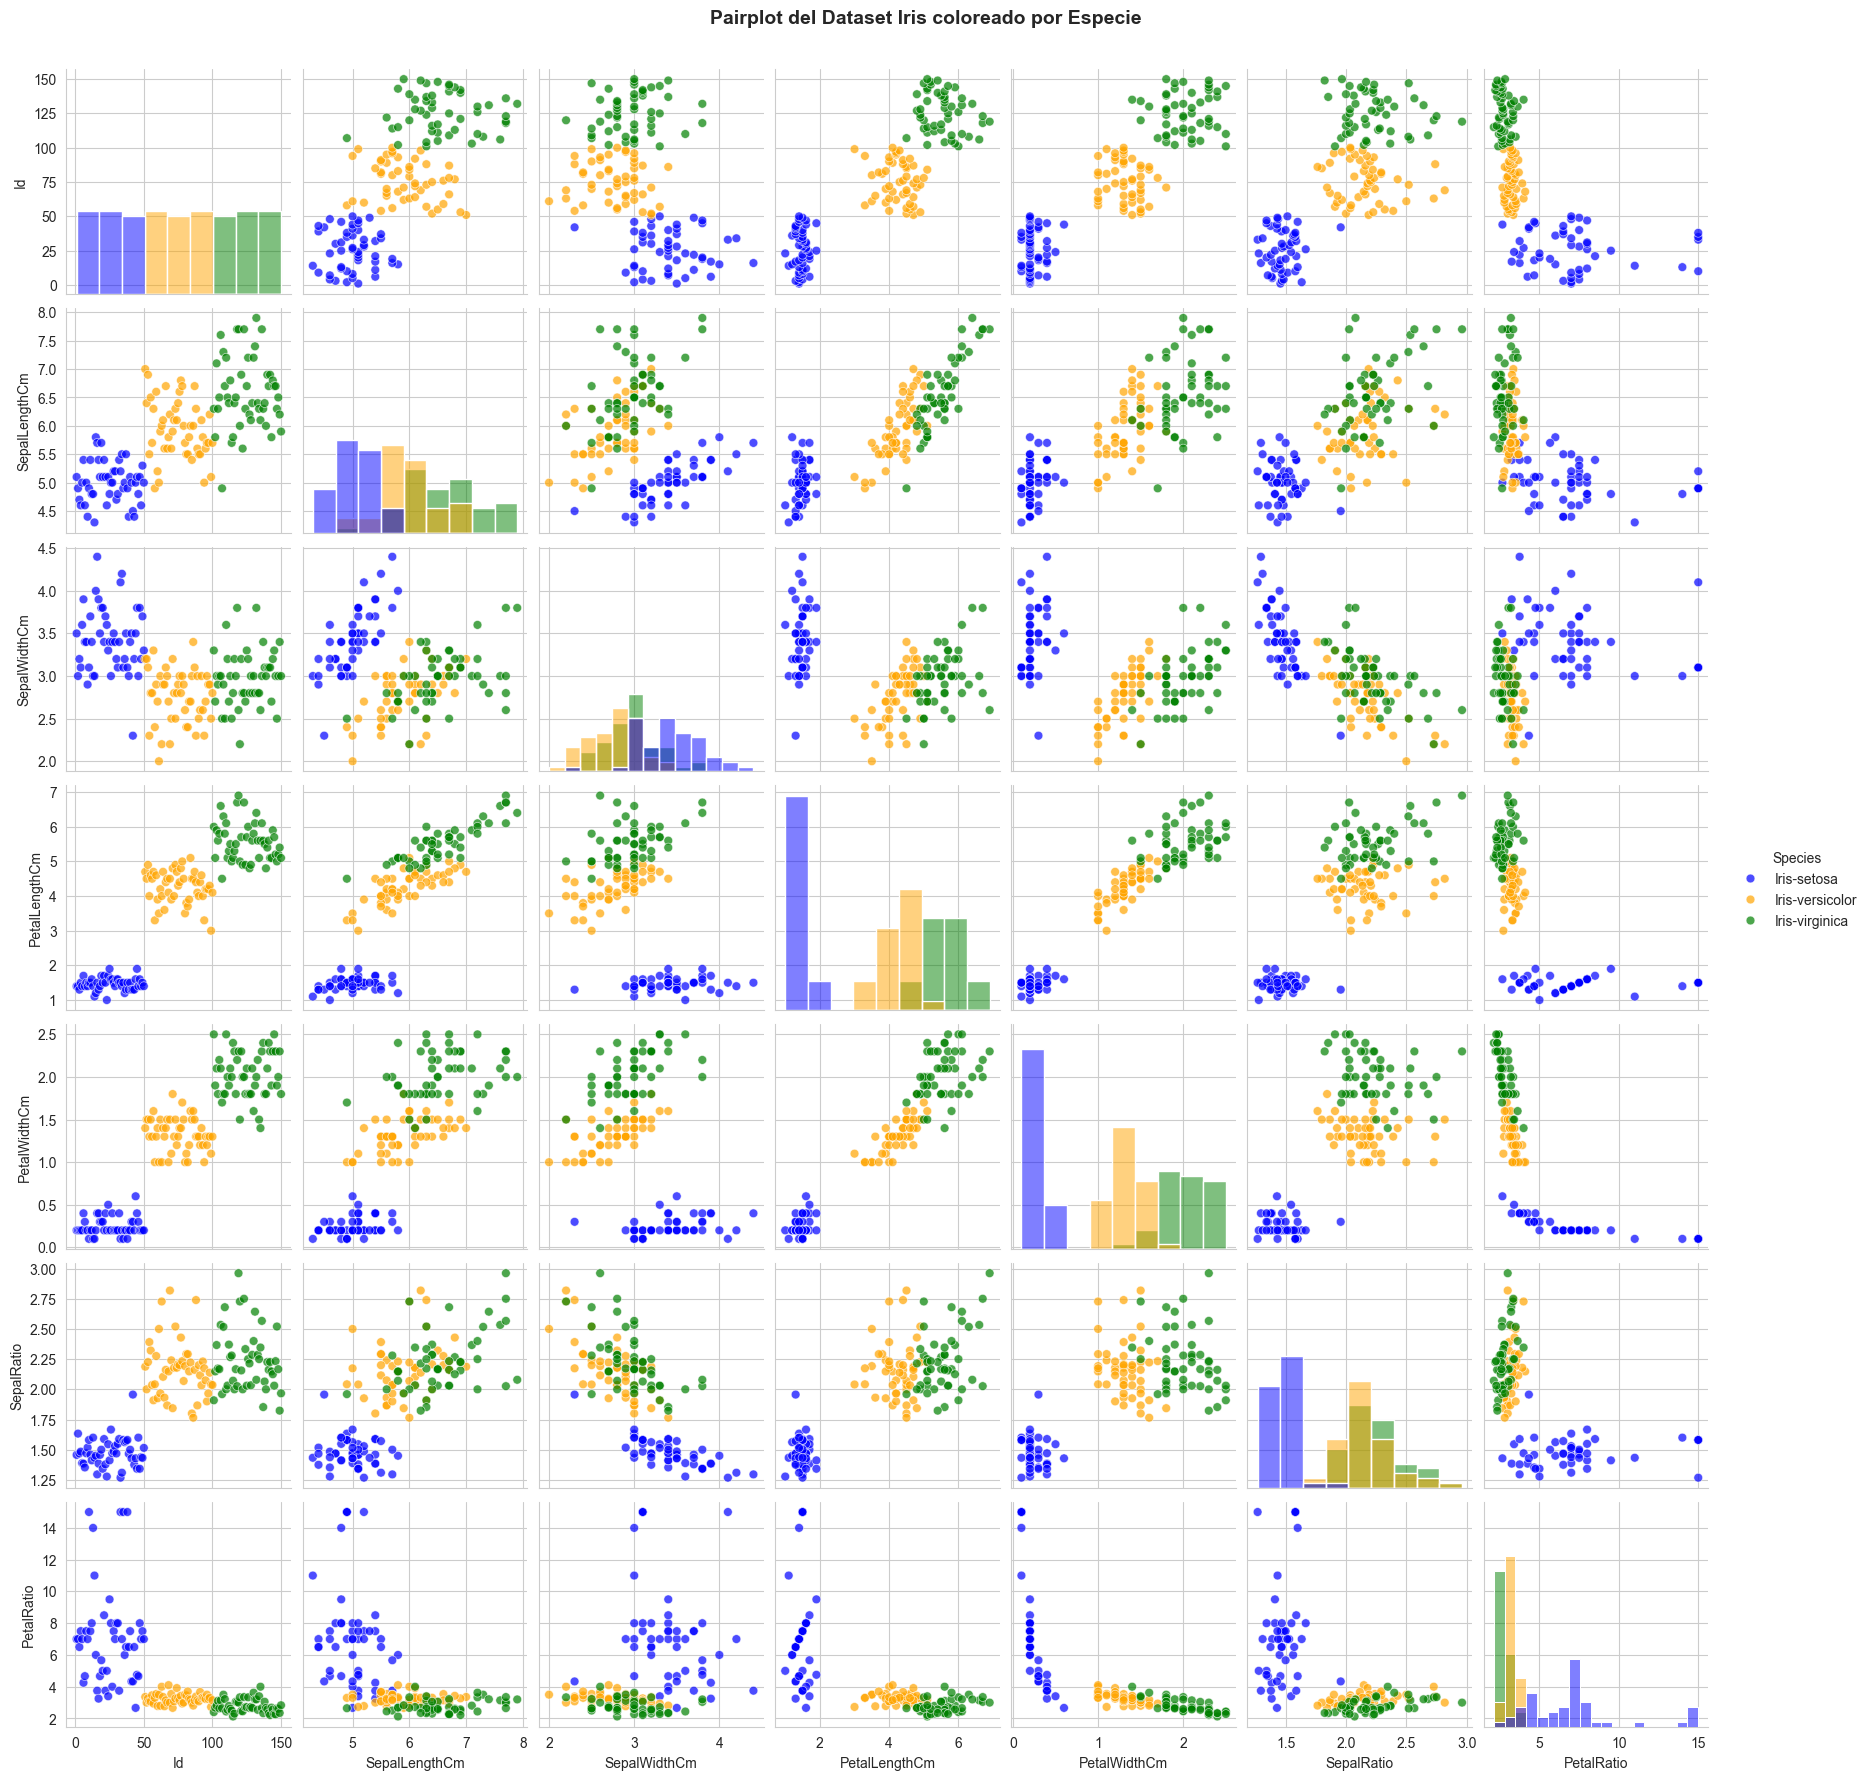

In [13]:
# 4. PAIRPLOT - Vista general coloreada por especie
print("="*50)
print("PAIRPLOT - VISTA GENERAL DE TODAS LAS RELACIONES")
print("="*50)

# Usar seaborn para crear un pairplot
pair_plot = sns.pairplot(df_clean, hue='Species', palette=colors, 
                         diag_kind='hist', plot_kws={'alpha': 0.7, 's': 40})
pair_plot.fig.suptitle('Pairplot del Dataset Iris coloreado por Especie', 
                        y=1.02, fontsize=14, fontweight='bold')

plt.show()

MATRIZ DE CORRELACIÓN

Matriz de correlación:
               SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
SepalLengthCm          1.000        -0.109          0.872         0.818
SepalWidthCm          -0.109         1.000         -0.421        -0.357
PetalLengthCm          0.872        -0.421          1.000         0.963
PetalWidthCm           0.818        -0.357          0.963         1.000


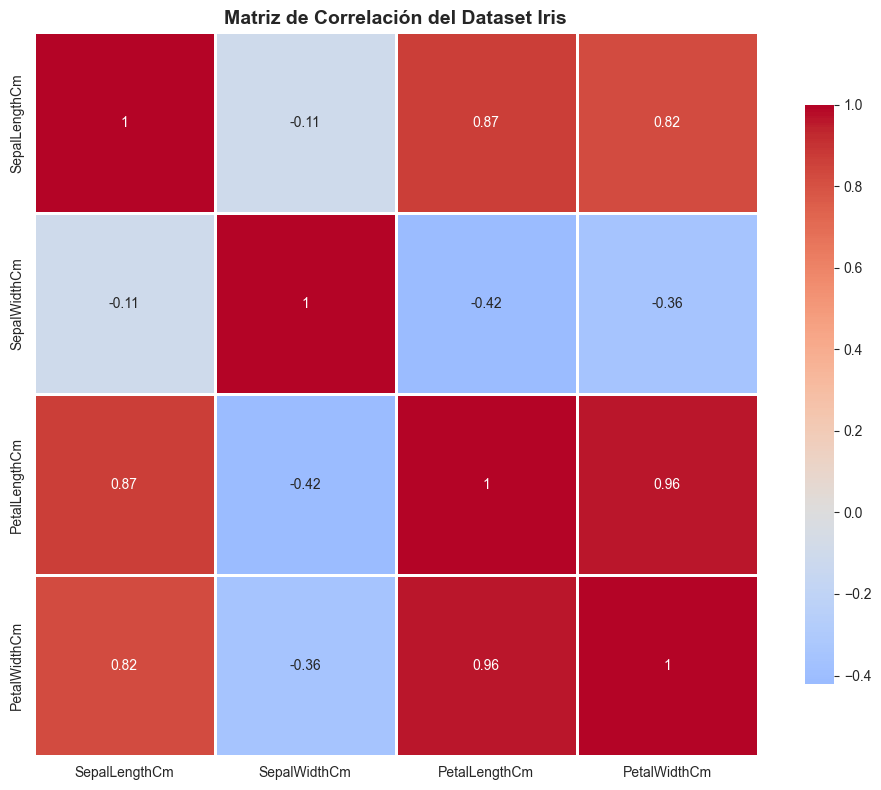

In [14]:
# 5. ANÁLISIS DE CORRELACIÓN
print("="*50)
print("MATRIZ DE CORRELACIÓN")
print("="*50)

# Calcular la matriz de correlación (excluyendo Id y Species)
numeric_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
corr_matrix = df_clean[numeric_cols].corr()

print("\nMatriz de correlación:")
print(corr_matrix)

# Visualizar la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlación del Dataset Iris', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Conclusiones del Análisis

Basado en el análisis descriptivo y visualización del dataset Iris, podemos extraer varias conclusiones importantes.

In [15]:
# Generar conclusiones automáticas basadas en los datos

# Encontrar la especie con mayor/media valores en cada característica
conclusions = []

for feature in features:
    means_by_species = df_clean.groupby('Species')[feature].mean()
    max_species = means_by_species.idxmax()
    min_species = means_by_species.idxmin()
    max_val = means_by_species.max()
    min_val = means_by_species.min()
    
    print(f"{feature}:")
    print(f"  - Mayor media: {max_species} ({max_val:.2f}cm)")
    print(f"  - Menor media: {min_species} ({min_val:.2f}cm)")
    print()

SepalLengthCm:
  - Mayor media: Iris-virginica (6.59cm)
  - Menor media: Iris-setosa (5.01cm)

SepalWidthCm:
  - Mayor media: Iris-setosa (3.42cm)
  - Menor media: Iris-versicolor (2.77cm)

PetalLengthCm:
  - Mayor media: Iris-virginica (5.55cm)
  - Menor media: Iris-setosa (1.46cm)

PetalWidthCm:
  - Mayor media: Iris-virginica (2.03cm)
  - Menor media: Iris-setosa (0.24cm)



### Conclusiones principales:

1. **Iris-setosa es fácilmente separable**: Las mediciones de pétalos de Iris-setosa son claramente más pequeñas que las de las otras dos especies. Esto se observa claramente en los boxplots y scatter plots.

2. **Iris-virginica tiende a ser más grande**: En general, Iris-virginica tiene las mayores mediciones para la mayoría de las características, especialmente en longitud y ancho del pétalo.

3. **Iris-versicolor está en el medio**: Esta especie muestra características intermedias entre setosa y virginica.

4. **Correlación fuerte entre longitud y ancho del pétalo**: Existe una correlación positiva fuerte entre estas dos variables (se puede observar en la matriz de correlación).

5. **Sépalo vs Pétalo**: La variabilidad en las mediciones del pétalo es mayor que en el sépalo, lo que hace que el pétalo sea una mejor característica para la clasificación.

6. **Superposición entre versicolor y virginica**: A diferencia de setosa, estas dos especies tienen cierta superposición en sus mediciones, lo que las hace más difíciles de separar perfectamente.

## 9. Ejercicio integrador

Realiza las siguientes tareas:

1. Calcula la correlación entre todas las características y encuentra el par con mayor correlación.
2. Identifica qué especie tiene la mayor variabilidad (desviación estándar) en el ancho del sépalo.
3. Crea un nuevo gráfico que muestre la relación entre la relación sépalo (SepalRatio) y la relación pétalo (PetalRatio), coloreado por especie.
4. Encuentra la muestra (fila) con la mayor longitud de pétalo y muestra toda su información.
5. Redacta tres conclusiones adicionales basadas en tus descubrimientos.

### Entregable

Un notebook con código ejecutable, gráficos y una sección final llamada **Conclusiones**.

In [16]:
# Espacio para el ejercicio del alumnado

# Pista para el ejercicio 1: usar df_clean.corr()
# Pista para el ejercicio 2: usar groupby + std()
# Pista para el ejercicio 3: usar scatter plot con SepalRatio y PetalRatio
# Pista para el ejercicio 4: usar df_clean['PetalLengthCm'].idxmax()

print("¡Completa el ejercicio integrador arriba!")

¡Completa el ejercicio integrador arriba!
